# India Crime Dataset — Exploratory Analysis

Exploring crime records across Indian cities: crime types, weapons used, victim demographics, and time trends. Focused deep-dive on Delhi as a case study.

## 1. Load Data

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\Shreya\Desktop\Projects\crime_dataset_india.csv")
df.head()

,Report Number,Date Reported,Date of Occurrence,Time of Occurrence,City,Crime Code,Crime Description,Victim Age,Victim Gender,Weapon Used,Crime Domain,Police Deployed,Case Closed,Date Case Closed
0,1,02-01-2020 00:00,01-01-2020 00:00,01-01-2020 01:11,Ahmedabad,576,IDENTITY THEFT,16,M,Blunt Object,Violent Crime,13,No,NaN
1,2,01-01-2020 19:00,01-01-2020 01:00,01-01-2020 06:26,Chennai,128,HOMICIDE,37,M,Poison,Other Crime,9,No,NaN
2,3,02-01-2020 05:00,01-01-2020 02:00,01-01-2020 14:30,Ludhiana,271,KIDNAPPING,48,F,Blunt Object,Other Crime,15,No,NaN
3,4,01-01-2020 05:00,01-01-2020 03:00,01-01-2020 14:46,Pune,170,BURGLARY,49,F,Firearm,Other Crime,1,Yes,29-04-2020 05:00
4,5,01-01-2020 21:00,01-01-2020 04:00,01-01-2020 16:51,Pune,421,VANDALISM,30,F,Other,Other Crime,18,Yes,08-01-2020 21:00


## 2. Data Overview & Cleaning

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40160 entries, 0 to 40159
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Report Number       40160 non-null  int64
 1   Date Reported       40160 non-null  str  
 2   Date of Occurrence  40160 non-null  str  
 3   Time of Occurrence  40160 non-null  str  
 4   City                40160 non-null  str  
 5   Crime Code          40160 non-null  int64
 6   Crime Description   40160 non-null  str  
 7   Victim Age          40160 non-null  int64
 8   Victim Gender       40160 non-null  str  
 9   Weapon Used         34370 non-null  str  
 10  Crime Domain        40160 non-null  str  
 11  Police Deployed     40160 non-null  int64
 12  Case Closed         40160 non-null  str  
 13  Date Case Closed    20062 non-null  str  
dtypes: int64(4), str(10)
memory usage: 4.3 MB


In [3]:
df.isnull().sum()

Report Number             0
Date Reported             0
Date of Occurrence        0
Time of Occurrence        0
City                      0
Crime Code                0
Crime Description         0
Victim Age                0
Victim Gender             0
Weapon Used            5790
Crime Domain              0
Police Deployed           0
Case Closed               0
Date Case Closed      20098
dtype: int64

In [4]:
# Sanity checks
print("Duplicate columns:", list(df.columns[df.columns.duplicated()]))
print("Index is unique:", df.index.is_unique)

Duplicate columns: []
Index is unique: True


## 3. Feature Engineering — Date & Time

Parsing date/time fields so we can analyze trends by year, month, and time of day.

In [5]:
df['Date of Occurrence'] = pd.to_datetime(df['Date of Occurrence'])
df['Year'] = df['Date of Occurrence'].dt.year
df['Month'] = df['Date of Occurrence'].dt.month_name()

df['Time of Occurrence'] = pd.to_datetime(df['Time of Occurrence'], format='%d-%m-%Y %H:%M')
df['Time'] = df['Time of Occurrence'].dt.strftime('%I:%M:%S %p')

df[['Date of Occurrence', 'Year', 'Month', 'Time']].head()

,Date of Occurrence,Year,Month,Time
0,2020-01-01 00:00:00,2020,January,01:11:00 AM
1,2020-01-01 01:00:00,2020,January,06:26:00 AM
2,2020-01-01 02:00:00,2020,January,02:30:00 PM
3,2020-01-01 03:00:00,2020,January,02:46:00 PM
4,2020-01-01 04:00:00,2020,January,04:51:00 PM


## 4. City-wise Crime Distribution

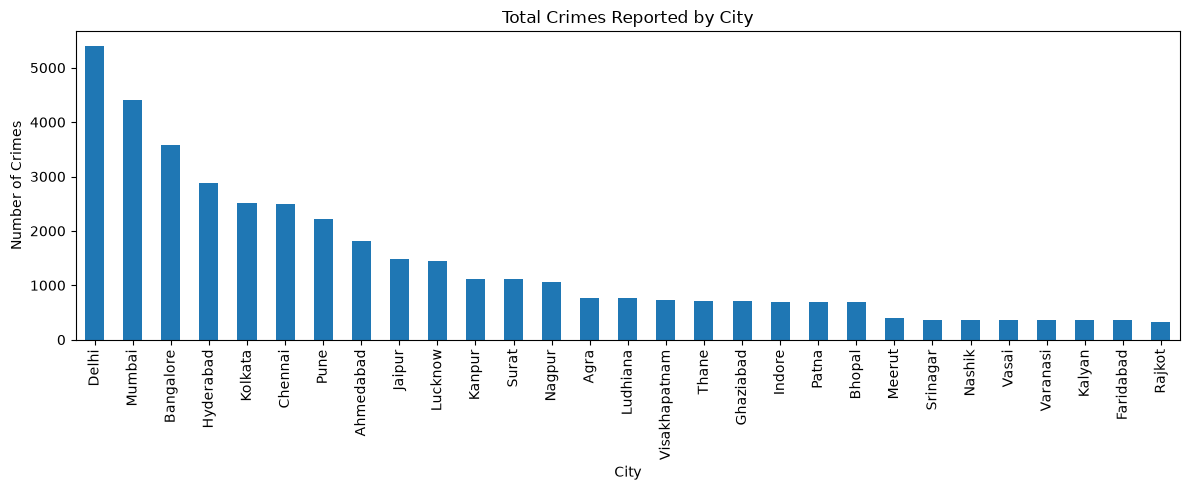

In [6]:
city_counts = df['City'].value_counts()

plt.figure(figsize=(12,5))
city_counts.plot.bar()
plt.title("Total Crimes Reported by City")
plt.xlabel("City")
plt.ylabel("Number of Crimes")
plt.tight_layout()
plt.show()

In [7]:
print("Number of unique cities:", df['City'].nunique())
top_cities = df['City'].value_counts().head(5).index
print("Top 5 cities by crime count:", list(top_cities))

Number of unique cities: 29
Top 5 cities by crime count: ['Delhi', 'Mumbai', 'Bangalore', 'Hyderabad', 'Kolkata']


## 5. Crime Type Analysis

In [8]:
crime_types = df['Crime Description'].unique()
print("Total unique crime types:", df['Crime Description'].nunique())
crime_types

Total unique crime types: 21


<StringArray>
[     'IDENTITY THEFT',            'HOMICIDE',          'KIDNAPPING',
            'BURGLARY',           'VANDALISM',             'ASSAULT',
    'VEHICLE - STOLEN',      'COUNTERFEITING',           'EXTORTION',
 'PUBLIC INTOXICATION',               'FRAUD',      'SEXUAL ASSAULT',
        'DRUG OFFENSE',               'ARSON',          'CYBERCRIME',
   'TRAFFIC VIOLATION',         'SHOPLIFTING',  'ILLEGAL POSSESSION',
     'FIREARM OFFENSE',             'ROBBERY',   'DOMESTIC VIOLENCE']
Length: 21, dtype: str

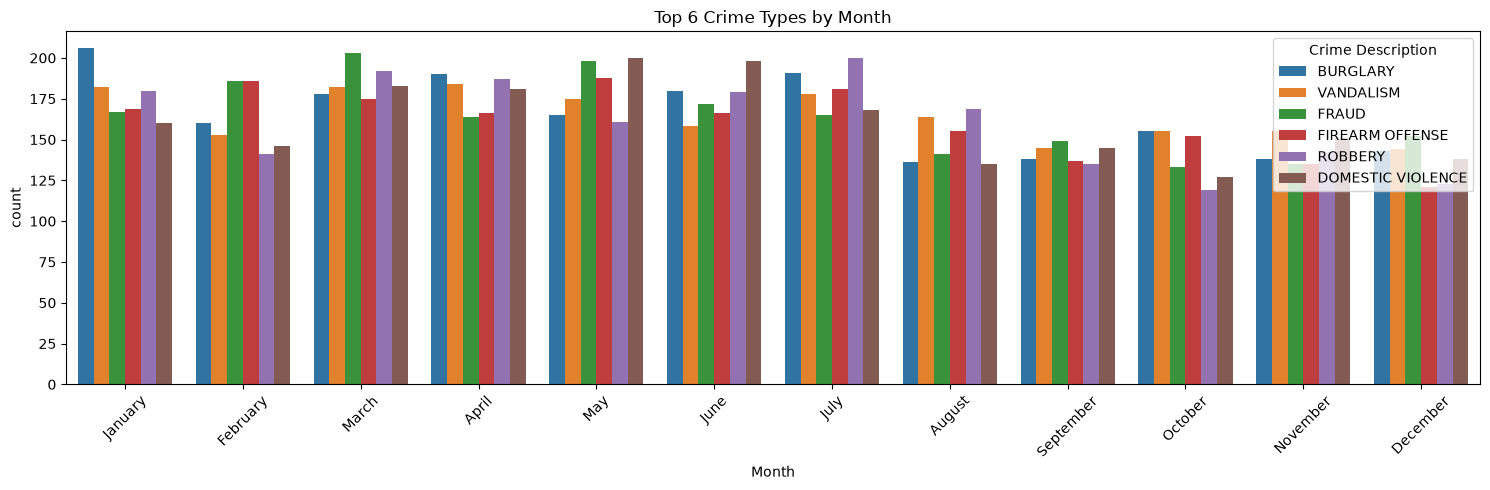

In [9]:
top_crimes = df['Crime Description'].value_counts().head(6).index

plt.figure(figsize=(15,5))
sns.countplot(x='Month', hue='Crime Description', data=df[df['Crime Description'].isin(top_crimes)])
plt.title("Top 6 Crime Types by Month")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

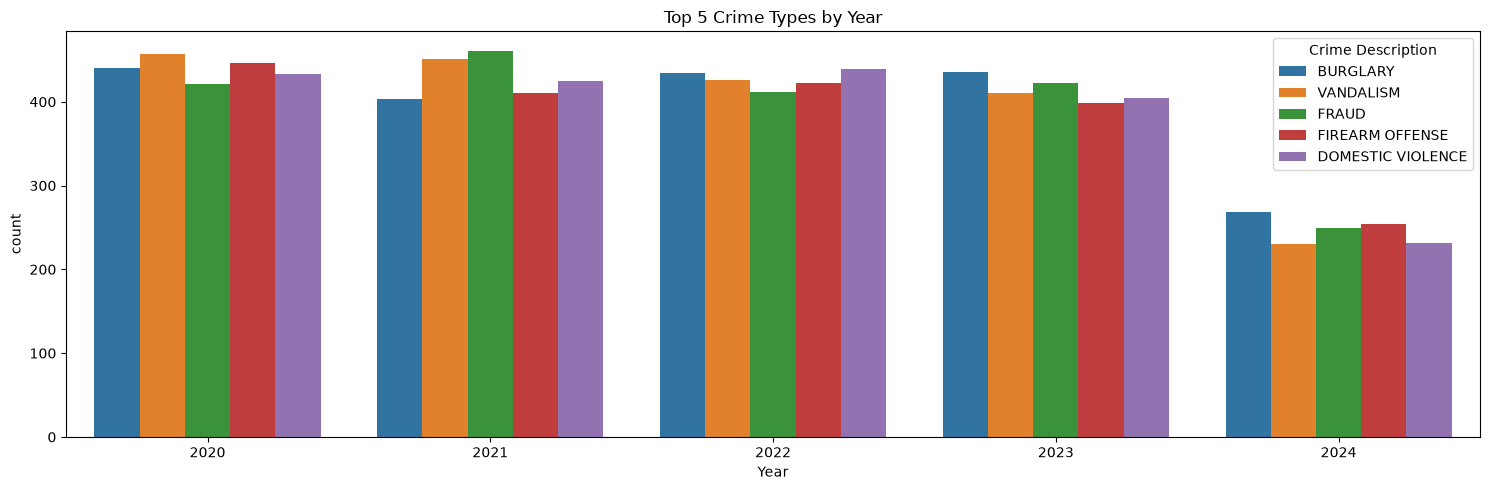

In [10]:
top5_crimes = df['Crime Description'].value_counts().head(5).index

plt.figure(figsize=(15,5))
sns.countplot(x='Year', hue='Crime Description', data=df[df['Crime Description'].isin(top5_crimes)])
plt.title("Top 5 Crime Types by Year")
plt.tight_layout()
plt.show()

## 6. City x Year x Crime Type — Pivot Views

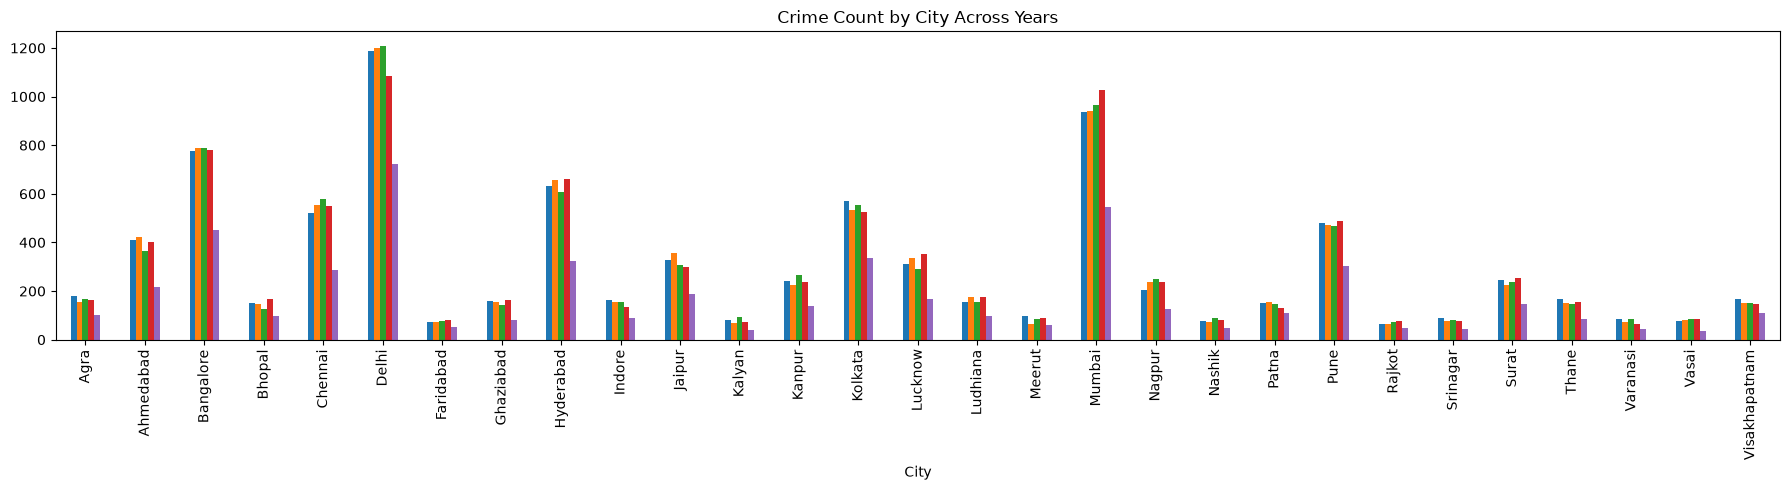

In [11]:
city_year_pivot = df[['City', 'Year', 'Crime Description']].pivot_table(index='City', columns='Year', aggfunc="count")
city_year_pivot.plot.bar(figsize=(18,5), legend=False)
plt.title("Crime Count by City Across Years")
plt.tight_layout()
plt.show()

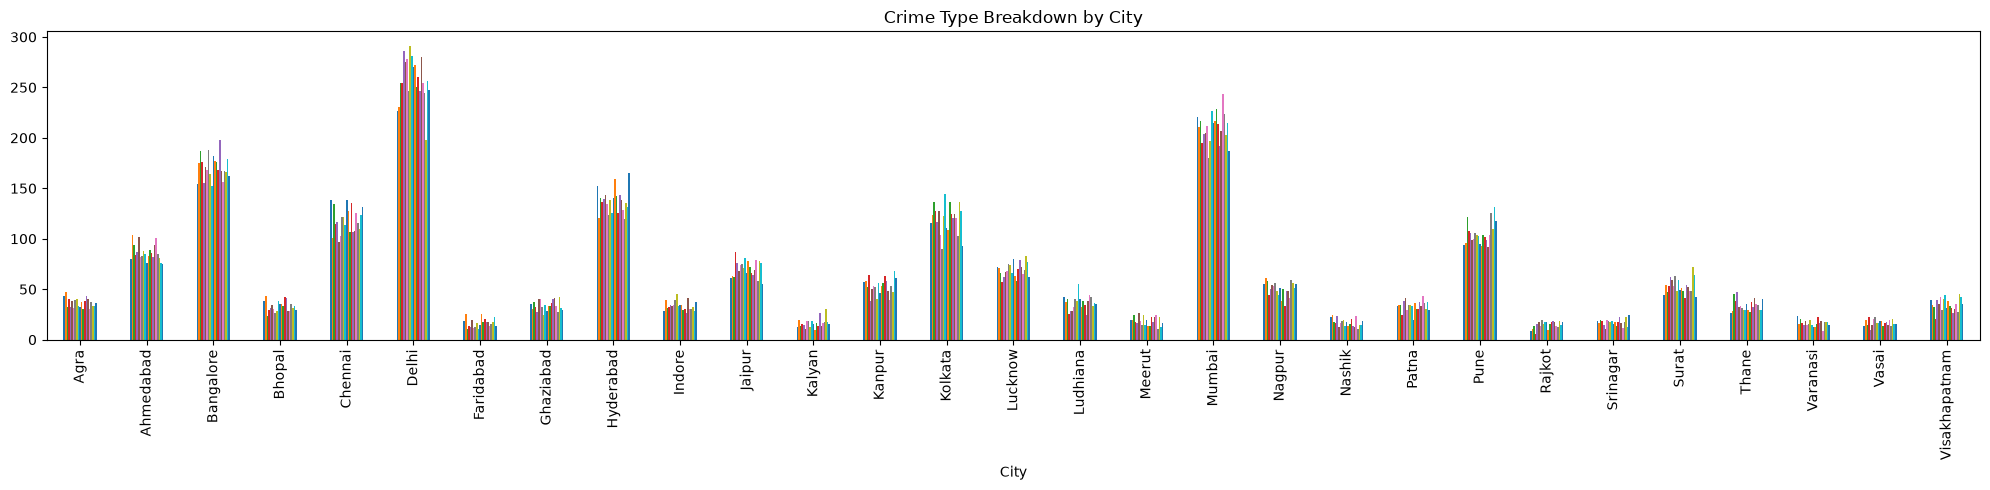

In [12]:
city_crimetype_pivot = df[['City', 'Year', 'Crime Description']].pivot_table(index='City', columns='Crime Description', aggfunc='count')
city_crimetype_pivot.plot.bar(figsize=(20,5), legend=False)
plt.title("Crime Type Breakdown by City")
plt.tight_layout()
plt.show()

## 7. Weapon Analysis

In [13]:
weapons_used = df['Weapon Used'].unique()
weapons_used

<StringArray>
['Blunt Object', 'Poison', 'Firearm', 'Other', 'Knife', 'Explosives', nan]
Length: 7, dtype: str

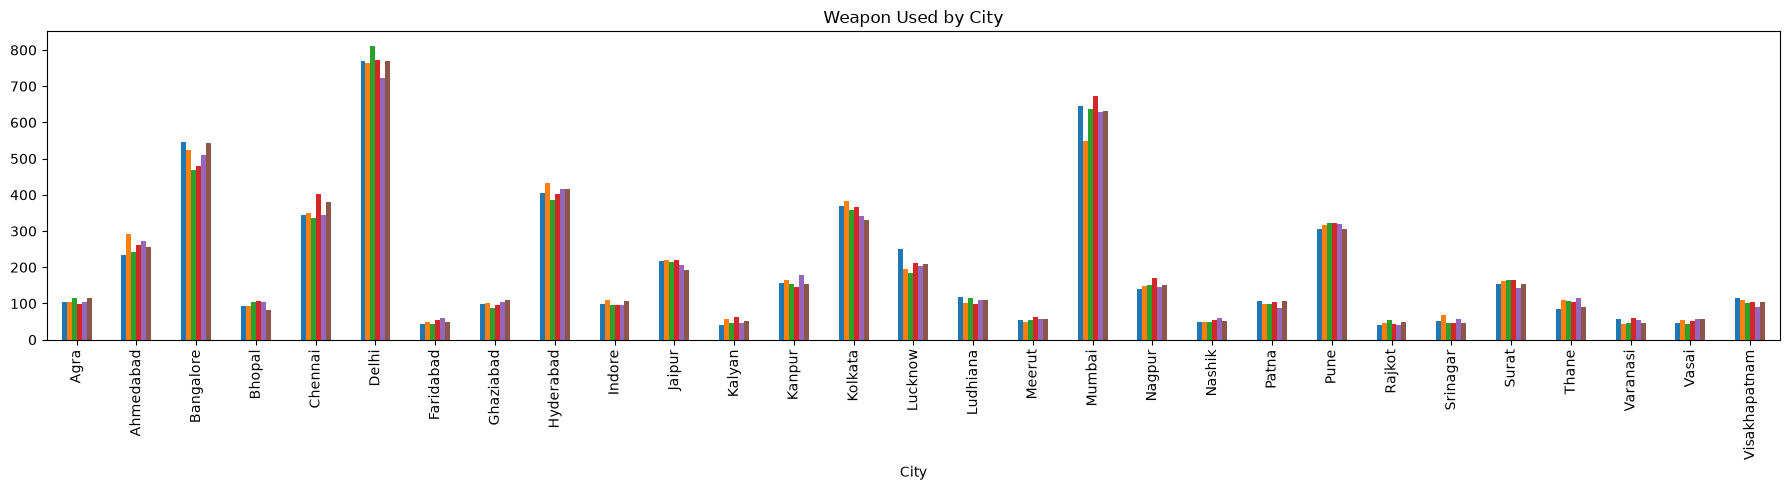

In [14]:
weapon_city_pivot = df[['City', 'Year', 'Weapon Used']].pivot_table(index='City', columns='Weapon Used', aggfunc='count')
weapon_city_pivot.plot.bar(figsize=(18,5), legend=False)
plt.title("Weapon Used by City")
plt.tight_layout()
plt.show()

In [15]:
knife_cases = df[df['Weapon Used'] == 'Knife']
knife_gender_pivot = knife_cases[['City', 'Year', 'Victim Gender']].pivot_table(index='City', columns='Victim Gender', aggfunc='count')
knife_gender_pivot

Year         
Victim Gender    F    M   X
City                       
Agra            71   21   7
Ahmedabad      163   81  18
Bangalore      270  152  57
Bhopal          59   40   9
Chennai        204  153  45
Delhi          405  279  89
Faridabad       34   19   2
Ghaziabad       56   33   8
Hyderabad      231  121  49
Indore          54   33  10
Jaipur         125   71  23
Kalyan          39   15   9
Kanpur          69   62  15
Kolkata        210  117  40
Lucknow        113   76  22
Ludhiana        62   29   7
Meerut          45   14   5
Mumbai         404  193  77
Nagpur         103   47  19
Nashik          28   19   7
Patna           55   41   8
Pune           179  107  35
Rajkot          27   15   1
Srinagar        26   13   6
Surat          103   53  10
Thane           59   32  12
Varanasi        31   23   5
Vasai           30   17   6
Visakhapatnam   67   27   9

## 8. Victim Demographics

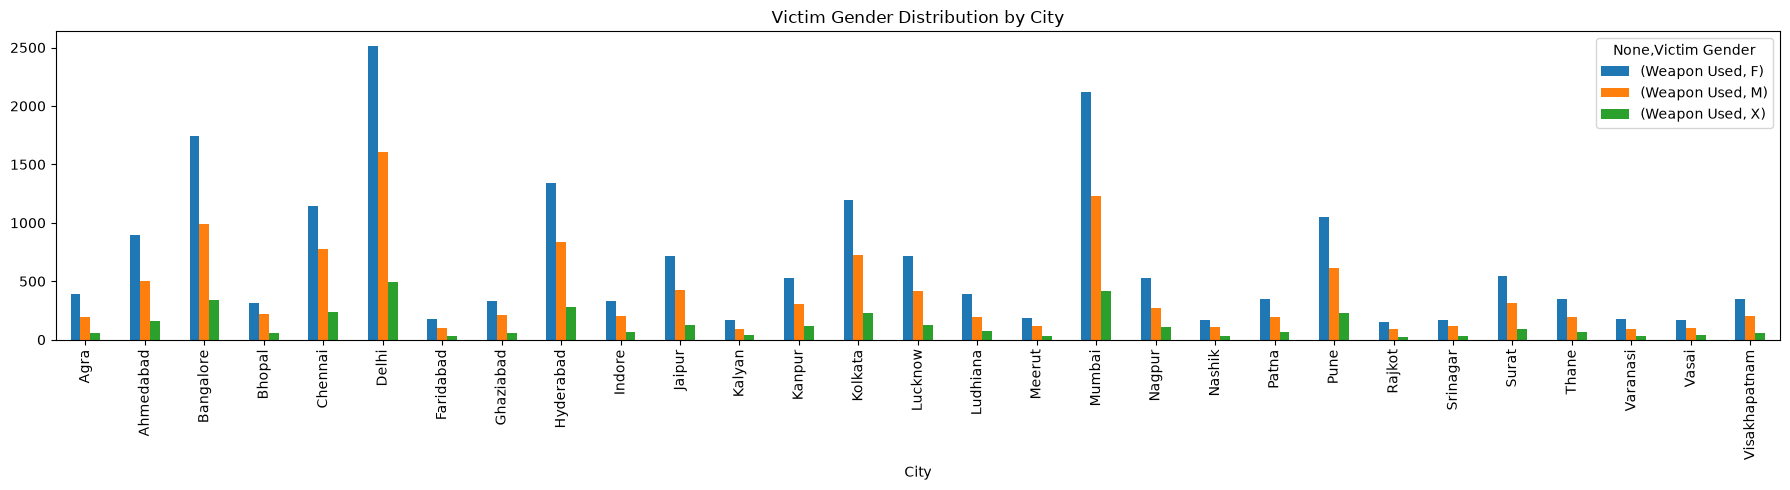

In [16]:
gender_city_pivot = df[['City', 'Victim Gender', 'Weapon Used']].pivot_table(index='City', columns='Victim Gender', aggfunc='count')
gender_city_pivot.plot.bar(figsize=(18,5), legend=True)
plt.title("Victim Gender Distribution by City")
plt.tight_layout()
plt.show()

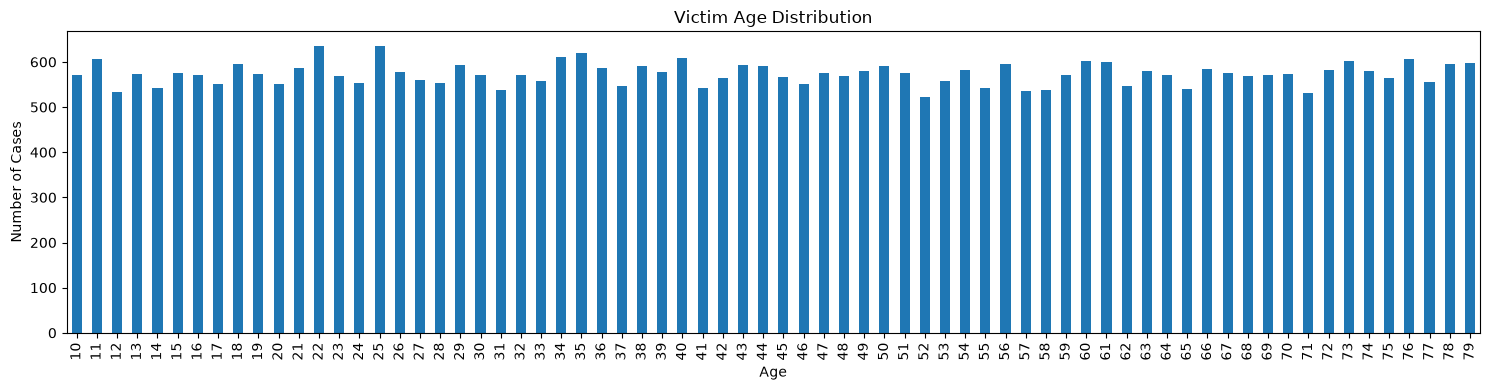

In [17]:
age_counts = df['Victim Age'].value_counts().sort_index()
age_counts.plot.bar(figsize=(15,4))
plt.title("Victim Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Cases")
plt.tight_layout()
plt.show()

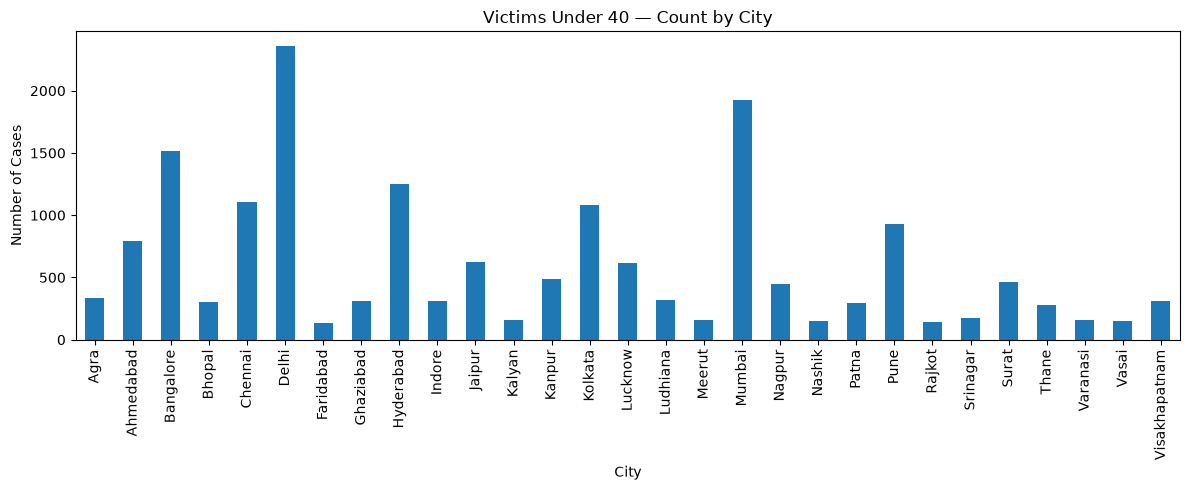

In [18]:
under_40 = df[df['Victim Age'] < 40]
under_40_city_counts = under_40.groupby('City')['Victim Age'].count()

under_40_city_counts.plot.bar(figsize=(12,5))
plt.title("Victims Under 40 — Count by City")
plt.xlabel("City")
plt.ylabel("Number of Cases")
plt.tight_layout()
plt.show()

## 9. Delhi Deep-Dive

Delhi has the highest crime volume in the dataset — a closer look at gender, weapon type, robbery cases, and case closure rate.

In [19]:
delhi_df = df[df['City'] == 'Delhi']
print("Total cases in Delhi:", len(delhi_df))
delhi_df['Victim Gender'].value_counts()

Total cases in Delhi: 5400


Victim Gender
F    2956
M    1858
X     586
Name: count, dtype: int64

In [20]:
delhi_df['Weapon Used'].value_counts()

Weapon Used
Firearm         811
Knife           773
Poison          769
Blunt Object    769
Explosives      763
Other           724
Name: count, dtype: int64

In [21]:
delhi_robbery_male = delhi_df[(delhi_df['Victim Gender'] == 'M') & (delhi_df['Crime Description'] == 'ROBBERY')]
print("Robbery cases with male victims in Delhi:", len(delhi_robbery_male))

Robbery cases with male victims in Delhi: 98


In [22]:
case_closed_counts = delhi_df['Case Closed'].value_counts()
case_closed_counts

Case Closed
No     2754
Yes    2646
Name: count, dtype: int64

In [23]:
closed_cases = delhi_df[delhi_df['Case Closed'] == 'Yes']
open_cases = delhi_df[delhi_df['Case Closed'] == 'No']

print("Closed cases by gender:")
print(closed_cases['Victim Gender'].value_counts())
print("\nOpen cases by gender:")
print(open_cases['Victim Gender'].value_counts())

Closed cases by gender:
Victim Gender
F    1458
M     907
X     281
Name: count, dtype: int64

Open cases by gender:
Victim Gender
F    1498
M     951
X     305
Name: count, dtype: int64


In [24]:
delhi_time_counts = delhi_df['Time'].value_counts().head(10)
delhi_time_counts

Time
05:15:00 PM    11
06:58:00 AM    11
07:26:00 AM    10
03:06:00 PM    10
02:23:00 PM    10
09:30:00 AM     9
02:16:00 AM     9
06:57:00 AM     9
06:14:00 AM     9
03:52:00 AM     9
Name: count, dtype: int64

## 10. Conclusion

- [Delhi] has the highest reported crime volume in this dataset.
- [Burglary] is the most common offense overall.
- Weapon use and victim demographics vary meaningfully by city — see Section 7–8.
- Delhi case closure rate: fill in from Section 9 output.
- Possible next steps: build a case-closure prediction model (classification), or a choropleth map of crime density by state/city.